# Vector Autoregression (VAR) with `numpyro_forecast`

This notebook ports the blog post [**Bayesian VAR in NumPyro**](https://juanitorduz.github.io/var_numpyro/) to the [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) package. A vector autoregression (VAR) models several time series jointly: each series is regressed on the past values of all series, and the shocks are correlated across series. We fit a VAR with two lags to the quarterly growth rates of US real GDP, consumption and investment, sample the posterior with NUTS, forecast 30 quarters ahead, and compute impulse response functions (IRFs), the standard tool to read a VAR.

The package provides the VAR pieces as reusable components. You do not write the lag recursion, the forecast loop or the IRF recursion yourself:

- [`var_step`](https://juanitorduz.github.io/numpyro_forecast/reference/var.var_step.html) turns sampled coefficients into a step for the [`ssoe`](https://juanitorduz.github.io/numpyro_forecast/reference/models.ssoe.html) building block. The block runs the in-sample recursion and the generative forecast.
- [`impulse_response`](https://juanitorduz.github.io/numpyro_forecast/reference/var.impulse_response.html) computes the responses for all posterior draws at once, with optional orthogonalization and cumulation.
- [`companion_matrix`](https://juanitorduz.github.io/numpyro_forecast/reference/var.companion_matrix.html) gives the stability check.
- [`minnesota_prior`](https://juanitorduz.github.io/numpyro_forecast/reference/priors.minnesota_prior.html) returns the moments of the Minnesota shrinkage prior. It lives in a separate module and is independent of the VAR code: the prior is always your own `numpyro.sample` call.

Some deliberate changes from the blog post:

- We model the growth rates in **percent** (`100 * diff(log)`), so the `Normal(0, 1)` and `HalfNormal(1)` priors are on a sensible scale.
- The in-sample recursion and the forecast run through `ssoe` and `var_step` instead of a hand-written `scan`. The likelihood still conditions on the first two observations, as in the blog post.
- The IRF section adds **orthogonalized** and **cumulative** responses.
- A final section refits the model with a **Minnesota prior** and compares the two fits.
- We drop the comparison with `statsmodels`, which is not a dependency of the package.

The components are deliberately minimal. If you need a complete Bayesian VAR toolkit (identification schemes, variance decompositions, lag selection), see [Impulso](https://github.com/thomaspinder/impulso) by Thomas Pinder. Its `MinnesotaPrior` parameterization and its batched moving-average recursion inspired the two helpers used here.

## Prepare notebook

In [1]:
import warnings

import arviz as az
import jax.numpy as jnp
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import xarray as xr
from jax import random
from jaxtyping import Float
from numpyro.infer import MCMC, NUTS

from numpyro_forecast import Horizon, eval_crps, predictions_to_datatree, ssoe, to_datatree
from numpyro_forecast.arrays import pad_future
from numpyro_forecast.priors import minnesota_prior
from numpyro_forecast.typing import Array, ForecastModel
from numpyro_forecast.var import companion_matrix, impulse_response, var_step

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
warnings.filterwarnings(
    "ignore", message="When multiple credible intervals are plotted", category=UserWarning
)

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype

## Read data

We use the `macrodata` dataset shipped with `statsmodels`: quarterly US macroeconomic data from 1959Q1 to 2009Q3, compiled from the Federal Reserve Bank of St. Louis (FRED) and released in the public domain. We read the CSV from the `statsmodels` repository and keep three series in billions of chained 2005 dollars: real GDP, real personal consumption and real gross private domestic investment.

The levels trend upward and are not stationary. We take log differences, which turn levels into quarter-on-quarter growth rates, and multiply by 100 to read them in percent. A VAR assumes stationarity, and growth rates are a standard way to get there for macro aggregates.

In [2]:
url = (
    "https://raw.githubusercontent.com/statsmodels/statsmodels/main/"
    "statsmodels/datasets/macrodata/macrodata.csv"
)
macro_df = pd.read_csv(url)
dates_all = pd.PeriodIndex.from_fields(
    year=macro_df["year"], quarter=macro_df["quarter"], freq="Q"
).to_timestamp()
names = ["realgdp", "realcons", "realinv"]
levels = macro_df[names].set_index(dates_all)
y_pct = (100 * np.log(levels).diff().dropna()).rename_axis("date")
print(
    f"shape: {y_pct.shape}, from {y_pct.index[0].to_period('Q')} to {y_pct.index[-1].to_period('Q')}"
)
y_pct.head()

shape: (202, 3), from 1959Q2 to 2009Q3


,realgdp,realcons,realinv
date,,,
1959-04-01,2.494213,1.528611,8.021268
1959-07-01,-0.119295,1.038598,-7.213104
1959-10-01,0.349453,0.108401,3.442511
1960-01-01,2.219018,0.953415,10.266377
1960-04-01,-0.468455,1.257243,-10.669385


In [3]:
y_pct.describe().T[["mean", "std", "min", "max"]].round(3)

,mean,std,min,max
realgdp,0.776,0.880,-2.071,3.859
realcons,0.837,0.694,-2.296,2.773
realinv,0.814,4.685,-19.316,12.209


Investment growth is about five times more volatile than GDP or consumption growth. Keep this in mind for the Minnesota prior section: the three series are not on a common scale.

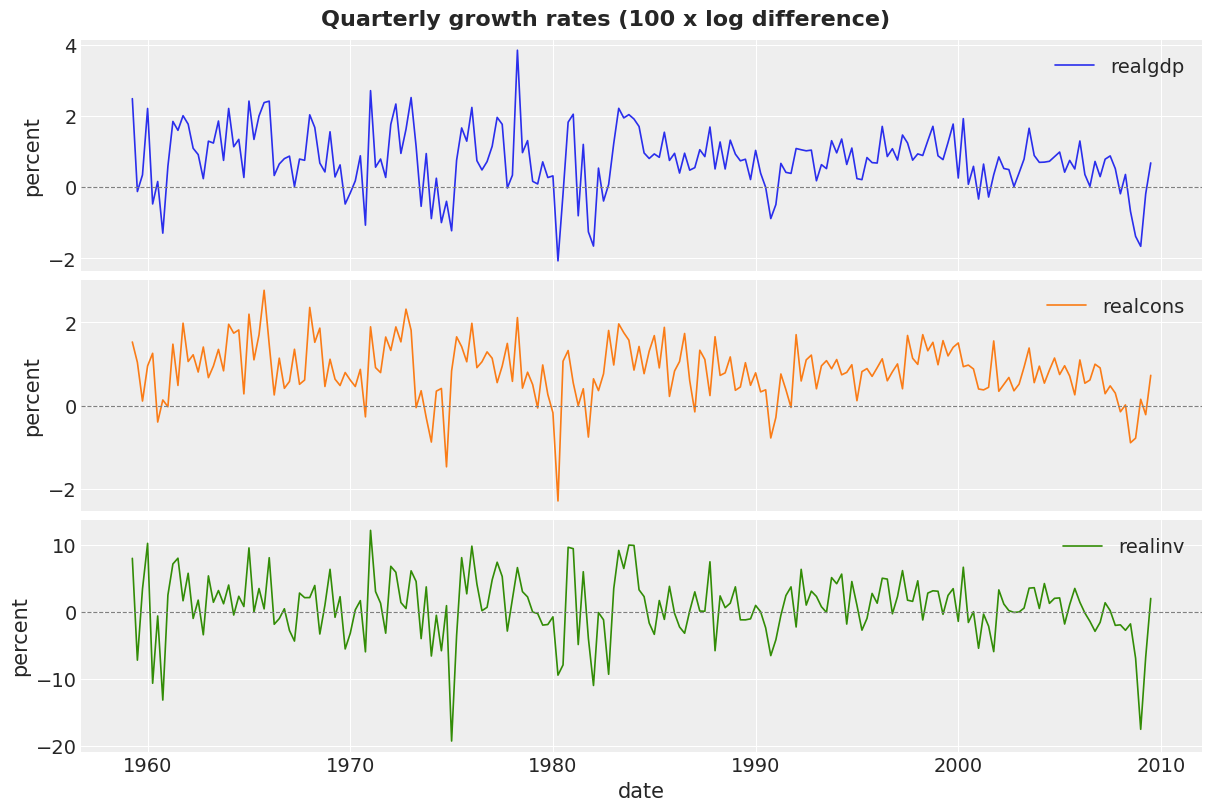

In [4]:
fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(12, 8), layout="constrained")
for ax, name, color in zip(axes, names, ("C0", "C1", "C2"), strict=True):
    ax.plot(y_pct.index, y_pct[name], color=color, lw=1.2, label=name)
    ax.axhline(0.0, color="gray", lw=0.8, ls="--")
    ax.set(ylabel="percent")
    ax.legend(loc="upper right")
axes[-1].set(xlabel="date")
fig.suptitle("Quarterly growth rates (100 x log difference)", fontsize=16, fontweight="bold");

## Model specification

Let $y_t \in \mathbb{R}^k$ be the vector of the $k = 3$ growth rates in quarter $t$. A VAR with $p$ lags is

$$
y_t = c + \sum_{l=1}^{p} \Phi_l \, y_{t-l} + \varepsilon_t,
\qquad
\varepsilon_t \sim \text{MultivariateNormal}(0, \Sigma),
$$

with an intercept vector $c$, one $k \times k$ coefficient matrix $\Phi_l$ per lag, and shocks that are independent over time but correlated across series through $\Sigma$. We parameterize the covariance through its Cholesky factor, $\Sigma = L L^\top$ with $L = \text{diag}(\sigma) \, L_\Omega$, where $\sigma$ holds the shock standard deviations and $L_\Omega$ is the Cholesky factor of the correlation matrix. This separates scales from correlations and gives each a natural prior:

\begin{align*}
c_i & \sim \text{Normal}(0, 1), \\
\sigma_i & \sim \text{HalfNormal}(1), \\
L_\Omega & \sim \text{LKJCholesky}(\eta = 1), \\
\Phi_{l, ij} & \sim \text{Normal}(0, 1).
\end{align*}

The LKJ prior with $\eta = 1$ is uniform over correlation matrices. We call the `Normal(0, 1)` prior on the $2 \times 3 \times 3 = 18$ coefficients *weakly informative* rather than diffuse: on percent-scaled growth rates it already rules out wild dynamics.

### The VAR as an innovations state-space model

Stack the last $p$ observations into a state $s_{t-1} = [y_{t-1}; \dots; y_{t-p}]$. The observation equation is $y_t = c + [\Phi_1 \cdots \Phi_p] \, s_{t-1} + \varepsilon_t$, and the state update shifts the window and appends $y_t$. The same error vector $\varepsilon_t$ drives both equations, and there is no separate state noise. In sample, given the parameters and the data, the state is known and the one-step-ahead mean $\mu_t$ is deterministic; the error is the residual $\varepsilon_t = y_t - \mu_t$. This is the single-source-of-error form, and it is exactly the contract of the `ssoe` building block:

1. **In sample**, `ssoe` runs a deterministic `jax.lax.scan` over the observed rows, computing $\mu_t$ from the lag window and pushing the observed $y_t$ into the window. It returns the means as `r.mu`, and we write the likelihood `obs ~ MultivariateNormal(r.mu, L)` ourselves.
2. **Out of sample**, when `covariates` extend beyond `data`, the block draws the future shocks $\varepsilon_{T+h}$ from the noise distribution at a separate `eps_future` site, feeds $y_{T+h} = \mu_{T+h} + \varepsilon_{T+h}$ back into the window, and returns the sampled paths as `r.y_future`.

The noise distribution is a `MultivariateNormal` over the series axis, so the future shocks are correlated across series exactly as the in-sample residuals are. `var_step(phi, intercept)` builds the step function from the sampled coefficients: the carry is the lag window with shape `(lags, series)` in natural time order (most recent row last), the mean is $c + \sum_l \Phi_l y_{t-l}$, and the carry update drops the oldest row and appends the new one.

### Data layout and the first $p$ observations

Time lives at axis `-2` and the series at axis `-1`, so the data is a `(time, 3)` array. The likelihood conditions on the first $p = 2$ rows, which seed the lag window (this is the conditional likelihood used by the blog post and by `statsmodels`): `y_init` holds these two rows, `data` holds the remaining 200 rows, and the forecast horizon is fixed by padding `data` with 30 zero rows through `pad_future`. The model reads only the first `h.t_obs` rows of `covariates` (the block checks this), so the padding rows are never used as data. They only set the horizon.

We write the model as a **factory** that takes the prior on $\Phi$ as an argument. The VAR code below never changes when we swap the prior in the last section.

In [5]:
p = 2
y_all = jnp.asarray(y_pct.to_numpy())  # (202, 3), float32
y_init = y_all[:p]  # the two rows that seed the lag window
data = y_all[p:]  # the 200 rows in the likelihood
future = 30
covariates_train = data  # fitting: no horizon
covariates_full = pad_future(data, future)  # forecasting: 30 unread rows fix the horizon
dates = y_pct.index[p:]
future_dates = pd.date_range(dates[-1], periods=future + 1, freq="QS")[1:]
time_coord = list(dates.append(future_dates))
print(f"y_init: {y_init.shape}, data: {data.shape}, covariates_full: {covariates_full.shape}")
print(f"forecast window: {future_dates[0].to_period('Q')} to {future_dates[-1].to_period('Q')}")

y_init: (2, 3), data: (200, 3), covariates_full: (230, 3)
forecast window: 2009Q4 to 2017Q1


In [6]:
def make_var_model(phi_prior: dist.Distribution, y_init: Array) -> ForecastModel:
    """Build an observed VAR model whose prior on the coefficients is ``phi_prior``.

    Parameters
    ----------
    phi_prior
        Prior distribution of the coefficient tensor, with event shape
        ``(lags, series, series)``.
    y_init
        The first ``lags`` rows of the series, which seed the lag window.

    Returns
    -------
    ForecastModel
        A plain ``(covariates, data=None)`` model function.
    """
    k = y_init.shape[-1]

    def var_model(covariates: Array, data: Array | None = None) -> None:
        h = Horizon.from_data(covariates, data)
        y = covariates[..., : h.t_obs, :]  # observed history only; never reads beyond t_obs

        # jnp.asarray only narrows numpyro's union return type for the type checker.
        intercept = jnp.asarray(
            numpyro.sample("intercept", dist.Normal(0.0, 1.0).expand([k]).to_event(1))
        )
        sigma = jnp.asarray(numpyro.sample("sigma", dist.HalfNormal(1.0).expand([k]).to_event(1)))
        l_omega = jnp.asarray(numpyro.sample("l_omega", dist.LKJCholesky(k, concentration=1.0)))
        phi = jnp.asarray(numpyro.sample("phi", phi_prior))
        scale_tril = sigma[..., :, None] * l_omega

        noise = dist.MultivariateNormal(jnp.zeros(k), scale_tril=scale_tril)
        r = ssoe(h, "eps", y, y_init, var_step(phi, intercept), noise)

        numpyro.deterministic("mu_t", r.mu)
        numpyro.sample("obs", dist.MultivariateNormal(r.mu, scale_tril=scale_tril), obs=h.data)
        if h.future > 0:
            numpyro.deterministic("forecast", r.y_future)

    return var_model


k = len(names)
weak_prior = dist.Normal(0.0, 1.0).expand([p, k, k]).to_event(3)
var_model = make_var_model(weak_prior, y_init)

## Inference with NUTS

We fit with four sequential NUTS chains of 1,000 warmup and 1,000 draws each. Fitting uses `covariates_train`, which has the same length as `data`, so the posterior holds only the parameters and the in-sample means. We pass the padded `covariates_full` to `to_datatree`, which runs the posterior predictive for the 200 in-sample rows and the 30 forecast rows in one call and names every dimension.

In [7]:
def fit_nuts(rng_key: Array, model: ForecastModel, data: Array, covariates: Array) -> MCMC:
    """Fit ``model`` with NUTS (4 chains, 1,000 warmup and 1,000 draws each)."""
    mcmc = MCMC(
        NUTS(model),
        num_warmup=1_000,
        num_samples=1_000,
        num_chains=4,
        chain_method="sequential",
        progress_bar=False,
    )
    mcmc.run(rng_key, covariates, data, extra_fields=("diverging",))
    return mcmc


def n_divergences(mcmc: MCMC) -> int:
    """Total number of divergent transitions across chains."""
    return int(np.asarray(mcmc.get_extra_fields()["diverging"]).sum())


# ``phi`` gets its own dimension names: ``az.summary`` mislabels the rows of a 3-D variable
# that shares a dimension (``series``) with 1-D variables (arviz 1.2).
coords = {
    "series": names,
    "equation": names,
    "lagged_series": names,
    "obs_dim": names,
    "lag": list(range(1, p + 1)),
}
posterior_dims = {
    "mu_t": ["time", "obs_dim"],
    "phi": ["lag", "equation", "lagged_series"],
    "intercept": ["series"],
    "sigma": ["series"],
}


def export(rng_key: Array, model: ForecastModel, posterior: dict[str, Array]) -> xr.DataTree:
    """Posterior, in-sample predictive and forecast draws as a labeled ArviZ tree."""
    return to_datatree(
        rng_key,
        model,
        posterior,
        data,
        covariates_full,
        num_chains=4,
        coords=coords,
        posterior_dims=posterior_dims,
        time_coord=time_coord,
    )

In [8]:
rng_key, rng_subkey = random.split(rng_key)
mcmc = fit_nuts(rng_subkey, var_model, data, covariates_train)
posterior = mcmc.get_samples()
print(f"divergences: {n_divergences(mcmc)}")

rng_key, rng_subkey = random.split(rng_key)
tree = export(rng_subkey, var_model, posterior)
tree

divergences: 0


<xarray.DataTree>
Group: /
│   Attributes:
│       inference_library:  numpyro
│       creation_library:   numpyro_forecast
│       sample_dims:        ['chain', 'draw']
├── Group: /posterior
│       Dimensions:        (chain: 4, draw: 1000, series: 3, l_omega_dim_0: 3,
│                           l_omega_dim_1: 3, time: 200, obs_dim: 3, lag: 2,
│                           equation: 3, lagged_series: 3)
│       Coordinates:
│         * chain          (chain) int64 32B 0 1 2 3
│         * draw           (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│         * series         (series) <U8 96B 'realgdp' 'realcons' 'realinv'
│         * l_omega_dim_0  (l_omega_dim_0) int64 24B 0 1 2
│         * l_omega_dim_1  (l_omega_dim_1) int64 24B 0 1 2
│         * time           (time) datetime64[us] 2kB 1959-10-01 ... 2009-07-01
│         * obs_dim        (obs_dim) <U8 96B 'realgdp' 'realcons' 'realinv'
│         * lag            (lag) int64 16B 1 2
│         * equation       (equation) <U8 96B 'realgdp' 'realcons' 'realinv'
│         * lagged_series  (lagged_series) <U8 96B 'realgdp' 'realcons' 'realinv'
│       Data variables:
│           intercept      (chain, draw, series) float32 48kB 0.1031 0.4838 ... -1.274
│           l_omega        (chain, draw, l_omega_dim_0, l_omega_dim_1) float32 144kB ...
│           mu_t           (chain, draw, time, obs_dim) float32 10MB 1.23 ... -0.5934
│           phi            (chain, draw, lag, equation, lagged_series) float32 288kB ...
│           sigma          (chain, draw, series) float32 48kB 0.7407 0.6767 ... 3.953
│       Attributes:
│           created_at:                 2026-09-04T06:35:23.810579+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /posterior_predictive
│       Dimensions:  (chain: 4, draw: 1000, time: 200, obs_dim: 3)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * time     (time) datetime64[us] 2kB 1959-10-01 1960-01-01 ... 2009-07-01
│         * obs_dim  (obs_dim) <U8 96B 'realgdp' 'realcons' 'realinv'
│       Data variables:
│           obs      (chain, draw, time, obs_dim) float32 10MB 2.553 1.829 ... -2.806
│       Attributes:
│           created_at:                 2026-09-04T06:35:24.034747+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:  (time: 200, obs_dim: 3)
│       Coordinates:
│         * time     (time) datetime64[us] 2kB 1959-10-01 1960-01-01 ... 2009-07-01
│         * obs_dim  (obs_dim) <U8 96B 'realgdp' 'realcons' 'realinv'
│       Data variables:
│           obs      (time, obs_dim) float32 2kB 0.3495 0.1084 3.443 ... 0.7265 2.02
│       Attributes:
│           created_at:                 2026-09-04T06:35:24.035308+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /constant_data
│       Dimensions:        (time: 200, covariate_dim: 3)
│       Coordinates:
│         * time           (time) datetime64[us] 2kB 1959-10-01 ... 2009-07-01
│         * covariate_dim  (covariate_dim) int64 24B 0 1 2
│       Data variables:
│           covariates     (time, covariate_dim) float32 2kB 0.3495 0.1084 ... 2.02
│       Attributes:
│           created_at:                 2026-09-04T06:35:24.035800+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /predictions
│       Dimensions:  (chain: 4, draw: 100

## Diagnostics

The summary table reports the posterior mean, standard deviation, $94\%$ HDI, effective sample sizes and $\hat{R}$ for every parameter. Rows of `phi` read `phi[lag, equation, lagged_series]`: the coefficient of the lagged series in the equation of the first series.

In [9]:
summary = az.summary(tree, var_names=["intercept", "sigma", "phi"], ci_kind="hdi", ci_prob=0.94)


def convergence_line(summary_: pd.DataFrame) -> str:
    """Worst r_hat and smallest bulk ESS of a summary table (its cells are formatted strings)."""
    r_hat = pd.to_numeric(summary_["r_hat"]).max()
    ess_bulk = int(pd.to_numeric(summary_["ess_bulk"]).min())
    return f"max r_hat: {r_hat:.3f}, min ess_bulk: {ess_bulk}"


print(convergence_line(summary))
summary

max r_hat: 1.000, min ess_bulk: 1856


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept[realgdp],0.24,0.102,0.051,0.43,2501,2405,1.00,0.002,0.0014
intercept[realcons],0.554,0.099,0.37,0.74,3479,3006,1.00,0.0017,0.0012
intercept[realinv],-1.74,0.49,-2.7,-0.84,2894,3068,1.00,0.009,0.0064
sigma[realgdp],0.747,0.0362,0.68,0.82,2865,2450,1.00,0.00068,0.00047
sigma[realcons],0.658,0.0334,0.6,0.72,4167,3304,1.00,0.00052,0.00037
sigma[realinv],3.884,0.186,3.6,4.3,3641,3008,1.00,0.0031,0.0023
"phi[1, realgdp, realgdp]",-0.059,0.14,-0.32,0.21,1922,2387,1.00,0.0032,0.0023
"phi[1, realgdp, realcons]",0.443,0.114,0.23,0.65,2293,2217,1.00,0.0024,0.0016
"phi[1, realgdp, realinv]",0.01,0.0227,-0.032,0.054,1878,2259,1.00,0.00052,0.00037
"phi[1, realcons, realgdp]",-0.056,0.144,-0.32,0.21,2295,2142,1.00,0.003,0.0021


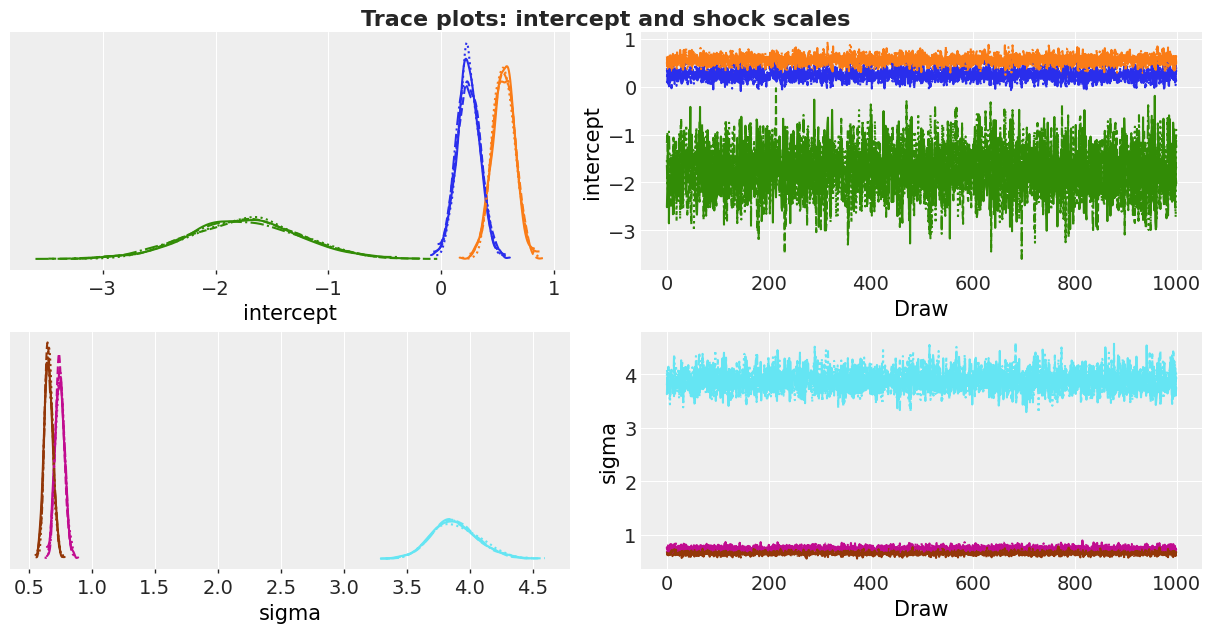

In [10]:
pc_trace = az.plot_trace_dist(
    tree, var_names=["intercept", "sigma"], compact=True, figure_kwargs={"figsize": (12, 6)}
)
pc_trace.viz["figure"].item().suptitle(
    "Trace plots: intercept and shock scales", fontsize=16, fontweight="bold", y=1.03
);

### Stability

A VAR is stable when all eigenvalues of its companion matrix have modulus below one. Stability is what makes the forecast revert to a finite unconditional mean and the impulse responses die out. Because the impulse responses are a nonlinear function of the coefficients, a single explosive posterior draw would dominate their posterior mean at long horizons, so we check the share of stable draws before the IRF section and mask the unstable draws if there are any.

In [11]:
phi_draws = jnp.asarray(posterior["phi"])  # (4000, 2, 3, 3)
radius = np.abs(np.linalg.eigvals(np.asarray(companion_matrix(phi_draws)))).max(axis=-1)
stable = radius < 1.0
print(
    f"stable draws: {stable.mean():.3f}, median spectral radius: {np.median(radius):.3f}, "
    f"max: {radius.max():.3f}"
)

stable draws: 1.000, median spectral radius: 0.597, max: 0.819


## In-sample fit

The posterior predictive of the `obs` site gives the one-step-ahead predictive distribution for every in-sample quarter. We plot the $50\%$ and $94\%$ HDI bands per series and score the fit with the continuous ranked probability score (CRPS).

In [12]:
def hdi_label(prob: float, prefix: str = "") -> str:
    r"""Legend label for an HDI band, e.g. ``$94\%$ HDI``."""
    percent = f"{prob:.0%}".replace("%", r"\%")
    return f"{prefix}${percent}$ HDI"


def stack_draws(group: str, tree_: xr.DataTree) -> Float[np.ndarray, " sample time series"]:
    """Flatten ``(chain, draw)`` of the ``obs`` variable of a tree group into a sample axis."""
    da = tree_[group].dataset["obs"]
    return da.stack(sample=("chain", "draw")).transpose("sample", "time", "obs_dim").to_numpy()


hdi_probs = (0.5, 0.94)
hdi_alphas = [0.6, 0.3]  # 50% band darker, 94% band lighter
dates_num = mdates.date2num(dates.to_pydatetime())
future_dates_num = mdates.date2num(future_dates.to_pydatetime())


def plot_fit_and_forecast(
    train_draws: Float[np.ndarray, " sample time series"],
    future_draws: Float[np.ndarray, " sample future series"] | None,
    title: str,
    n_last: int | None = None,
) -> None:
    """Facet the in-sample predictive (and optionally the forecast) per series.

    Parameters
    ----------
    train_draws
        In-sample posterior predictive draws ``(sample, time, series)``.
    future_draws
        Forecast draws ``(sample, future, series)``, or ``None`` for the in-sample plot only.
    title
        Figure title.
    n_last
        Plot only the last ``n_last`` in-sample quarters (``None`` for all).
    """
    start = 0 if n_last is None else train_draws.shape[1] - n_last
    x_train = dates_num[start:]
    observed = np.asarray(data)[start:]
    pc = az.plot_lm(
        predictions_to_datatree(train_draws[:, start:], x_train, names, observed=observed),
        y="obs",
        x="t",
        plot_dim="time",
        ci_kind="hdi",
        ci_prob=hdi_probs,
        smooth=False,
        col_wrap=1,
        visuals={
            "ci_band": {"color": "C0"},
            "observed_scatter": False,
            "pe_line": False,
            "xlabel": False,
            "ylabel": False,
        },
        aes={"alpha": ["prob"]},
        alpha=hdi_alphas,
        figure_kwargs={"figsize": (12, 9)},
    )
    train_bands = pc.viz["ci_band"]["t"].sel(series=names[0])
    handles = [train_bands.sel(prob=prob).item() for prob in (0.94, 0.5)]
    for handle, prob in zip(handles, (0.94, 0.5), strict=True):
        handle.set_label(hdi_label(prob, prefix="in-sample " if future_draws is not None else ""))
    if future_draws is not None:
        az.plot_lm(
            predictions_to_datatree(future_draws, future_dates_num, names),
            y="obs",
            x="t",
            plot_dim="time",
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=hdi_probs,
            smooth=False,
            visuals={
                "ci_band": {"color": "C1"},
                "observed_scatter": False,
                "pe_line": False,
                "xlabel": False,
                "ylabel": False,
            },
        )
        future_bands = pc.viz["ci_band"]["t"].sel(series=names[0])
        for prob in (0.94, 0.5):
            band = future_bands.sel(prob=prob).item()
            band.set_label(hdi_label(prob, prefix="forecast "))
            handles.append(band)
    for i, name in enumerate(names):
        ax = pc.get_target("t", {"series": name})
        (obs_line,) = ax.plot(x_train, observed[:, i], color="black", lw=1.2, label="observed")
        ax.axhline(0.0, color="gray", lw=0.8, ls="--")
        ax.set_title(name, fontsize=11)
        locator = mdates.AutoDateLocator()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    handles.append(obs_line)
    pc.get_target("t", {"series": names[0]}).legend(handles=handles, loc="upper left", fontsize=9)
    fig = pc.viz["figure"].item()
    fig.supxlabel("date")
    fig.supylabel("growth rate (percent)")
    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.02)


train_pp = stack_draws("posterior_predictive", tree)
crps_train = eval_crps(train_pp, data)
print(f"in-sample CRPS: {float(crps_train):.4f}")

in-sample CRPS: 0.9674


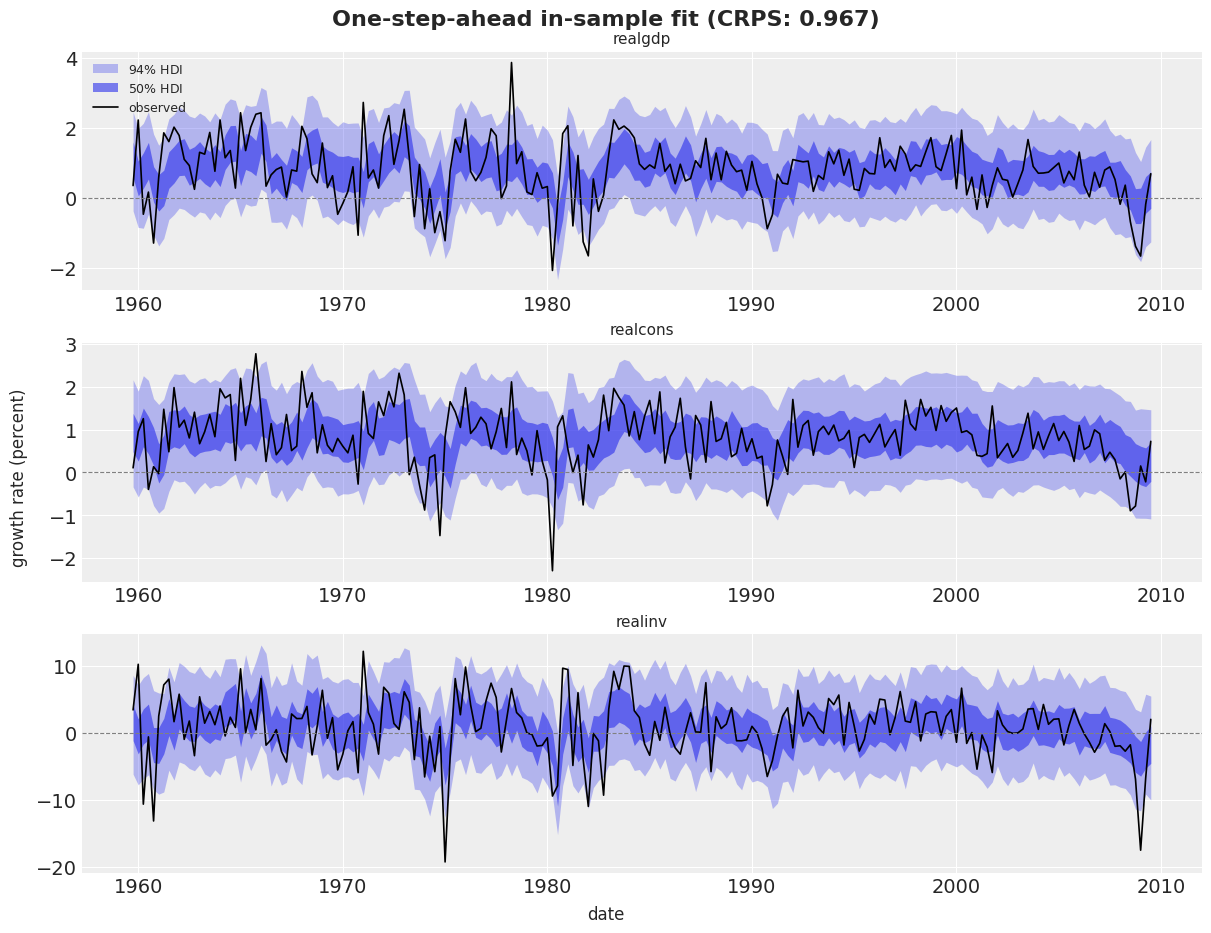

In [13]:
plot_fit_and_forecast(
    train_pp, None, title=f"One-step-ahead in-sample fit (CRPS: {float(crps_train):.3f})"
)

## Forecast

The `predictions` group of the tree holds the 30-quarter forecast paths. Each path draws its own correlated shocks and feeds them back through the lag window, so the uncertainty compounds over the horizon. We show the last 40 in-sample quarters for context.

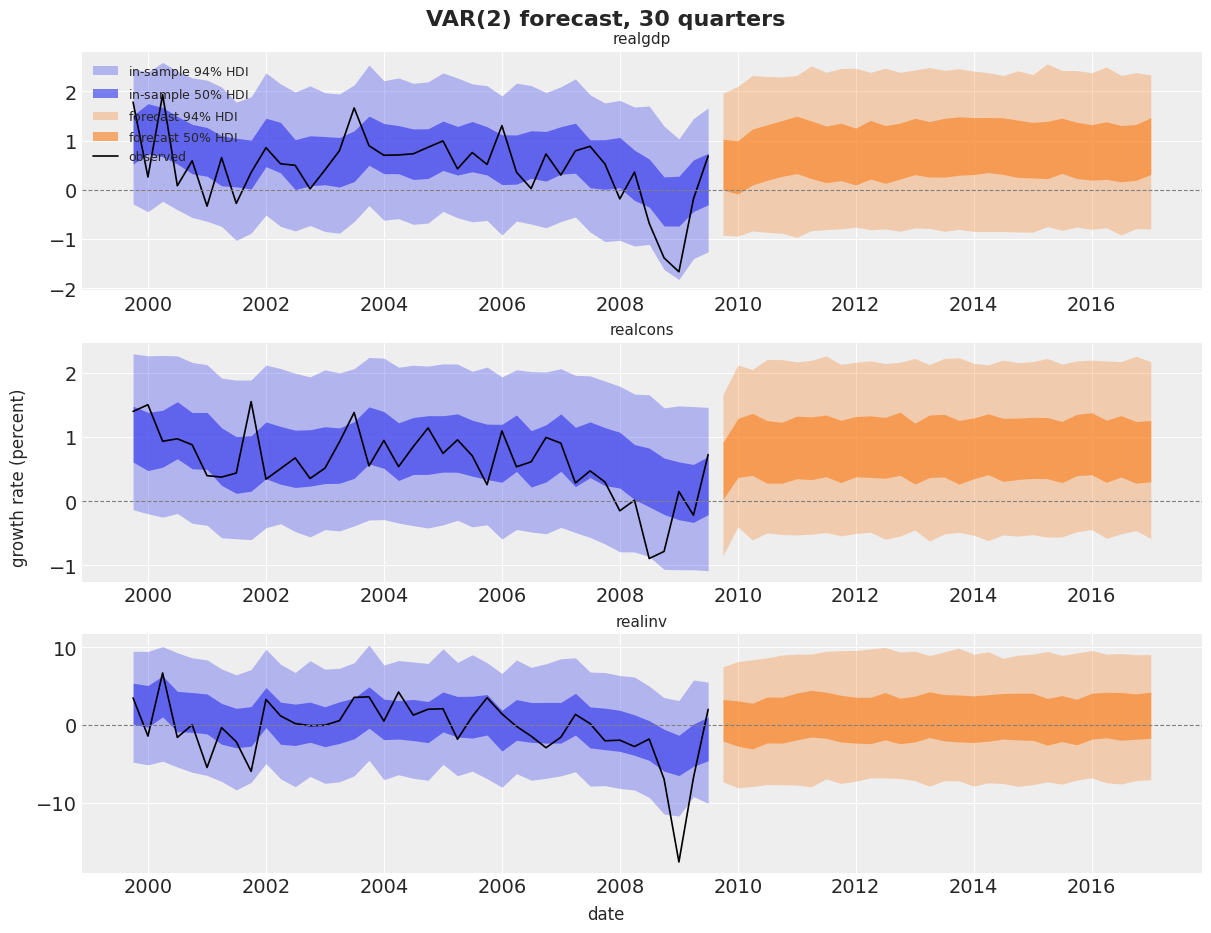

In [14]:
forecast_draws = stack_draws("predictions", tree)
plot_fit_and_forecast(train_pp, forecast_draws, title="VAR(2) forecast, 30 quarters", n_last=40)

The forecast bands widen over the first few quarters and then settle. For a stable VAR the forecast error covariance $\sum_{s < h} \Psi_s \Sigma \Psi_s^\top$ converges to the unconditional covariance of the process, and the forecast mean converges to the unconditional mean $(I - \sum_l \Phi_l)^{-1} c$. The posterior bands also carry parameter uncertainty, so they are a mixture over draws, but with every draw stable the same picture holds. The table shows the width of the $94\%$ HDI per series at a few horizons, and the printout compares the unconditional mean implied by the posterior means with the sample means and the mean forecast at the last horizon.

In [15]:
def hdi_width(draws: Float[np.ndarray, " sample time series"], prob: float) -> np.ndarray:
    """Width of the HDI of ``draws`` per time step and series."""
    da = xr.DataArray(np.asarray(draws), dims=["sample", "time", "series"])
    hdi = az.hdi(da, prob=prob, dim="sample")  # (time, series, ci_bound)
    return (hdi.sel(ci_bound="upper") - hdi.sel(ci_bound="lower")).to_numpy()


width_94 = hdi_width(forecast_draws, 0.94)
horizons = [1, 5, 10, 20, 30]
pd.DataFrame(
    width_94[[h - 1 for h in horizons]], index=pd.Index(horizons, name="h"), columns=names
).round(3)

,realgdp,realcons,realinv
h,,,
1,2.880,2.512,14.786
5,3.172,2.730,16.646
10,3.222,2.671,16.764
20,3.165,2.728,16.068
30,3.126,2.760,16.045


In [16]:
phi_mean = np.asarray(posterior["phi"]).mean(axis=0)
c_mean = np.asarray(posterior["intercept"]).mean(axis=0)
unconditional_mean = np.linalg.solve(np.eye(k) - phi_mean.sum(axis=0), c_mean)
pd.DataFrame(
    {
        "unconditional mean": unconditional_mean,
        "sample mean": np.asarray(data).mean(axis=0),
        "mean forecast at h=30": forecast_draws.mean(axis=0)[-1],
    },
    index=names,
).round(3)

,unconditional mean,sample mean,mean forecast at h=30
realgdp,0.789,0.772,0.790
realcons,0.838,0.832,0.826
realinv,0.950,0.818,1.018


## Impulse response functions

A forecast tells you where the system goes on average. An impulse response tells you how a shock to one series propagates to all series over time. For a stable VAR the moving-average (Wold) representation

$$
y_t = \mu + \sum_{h=0}^{\infty} \Psi_h \, \varepsilon_{t-h}
$$

exists, and the coefficient matrices follow the recursion

$$
\Psi_0 = I, \qquad \Psi_h = \sum_{j=1}^{\min(h, p)} \Phi_j \, \Psi_{h-j} \quad (h \geq 1).
$$

The entry $\Psi_h[i, j]$ is the response of series $i$, $h$ quarters after a unit shock to the reduced-form residual $\varepsilon_{t, j}$, with the other residuals held at zero. `impulse_response(phi, horizon)` runs this recursion for all posterior draws at once (the draws pass through the leading batch axis; no `vmap` is needed) and returns an array of shape `(draws, horizon + 1, series, series)`, indexed as `[draw, h, response, shock]`.

The recursion exists for any coefficients, but the representation and the decay $\Psi_h \to 0$ need stability, which we checked above. If some draws were unstable we would mask them here; the mask below is the identity when all draws are stable.

In [17]:
n_irf_steps = 10
irf_labels = [f"{response} response to {shock} shock" for response in names for shock in names]
irf_draws = impulse_response(phi_draws[stable], n_irf_steps)  # (draws, 11, 3, 3)
print(f"irf_draws: {irf_draws.shape}")
print("posterior mean responses at h = 0, 1, 2 (rows: response, columns: shock):")
print(np.round(np.asarray(irf_draws.mean(axis=0)[:3]), 3))

irf_draws: (4000, 11, 3, 3)
posterior mean responses at h = 0, 1, 2 (rows: response, columns: shock):
[[[ 1.     0.     0.   ]
  [ 0.     1.     0.   ]
  [ 0.     0.     1.   ]]

 [[-0.059  0.443  0.01 ]
  [-0.056  0.228  0.021]
  [-0.49   2.821  0.071]]

 [[-0.029  0.368  0.008]
  [-0.137  0.315  0.029]
  [ 0.066  1.271 -0.012]]]


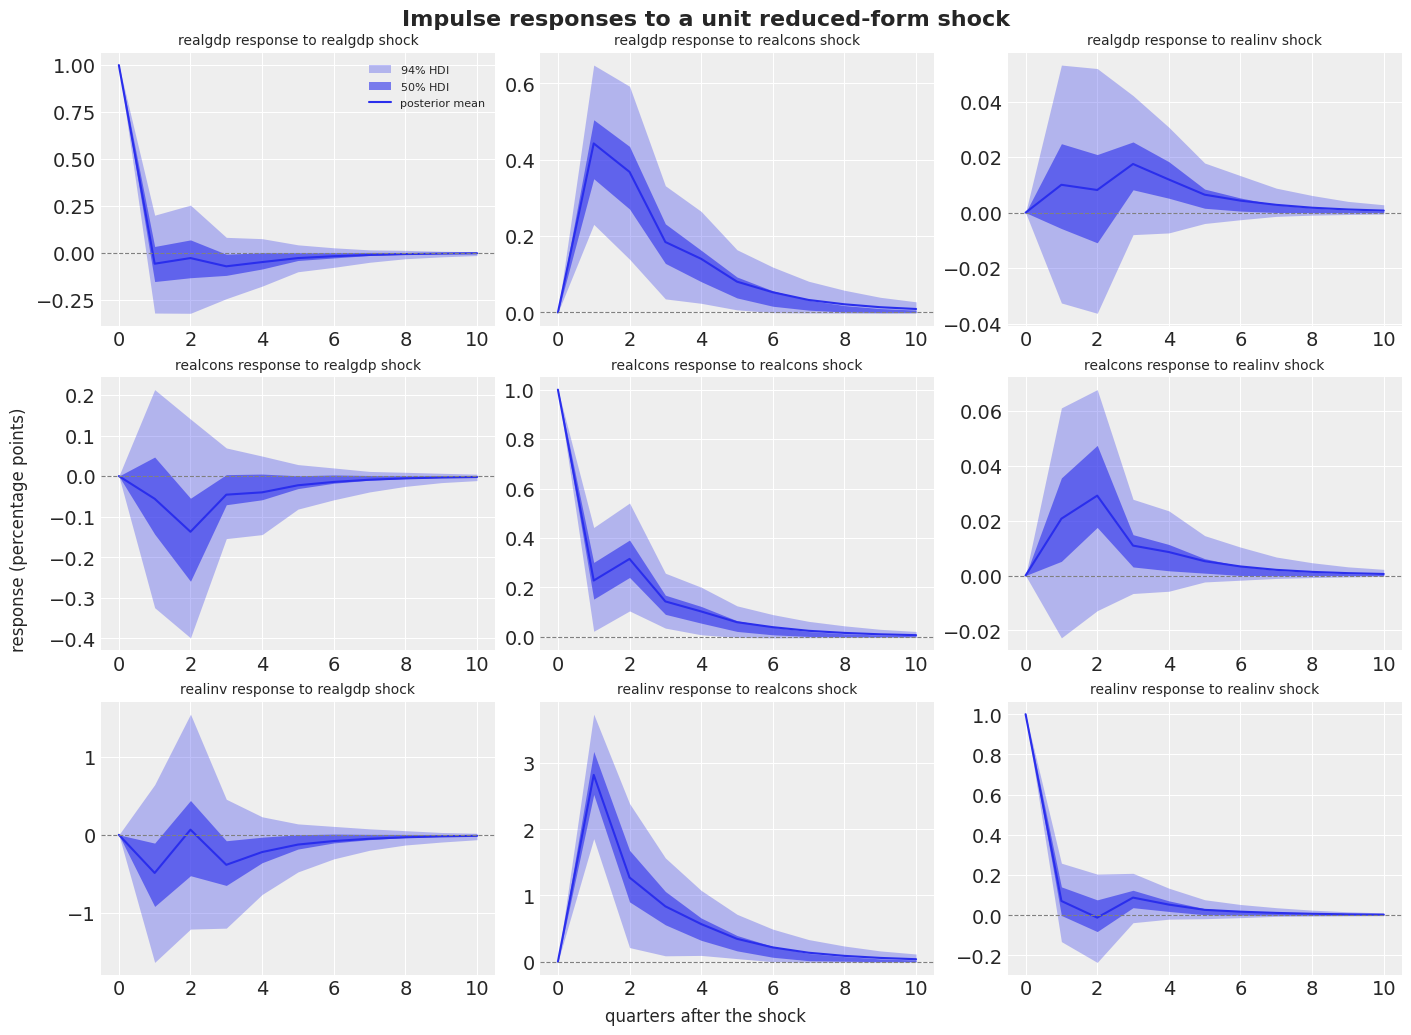

In [18]:
def plot_irf_grid(
    irf: Float[Array, " sample steps series series"],
    title: str,
    ylabel: str,
    overlay: Float[Array, " sample steps series series"] | None = None,
    overlay_label: str = "",
) -> None:
    """Plot a ``series x series`` grid of impulse responses with HDI bands.

    Parameters
    ----------
    irf
        Impulse response draws ``(sample, steps, response, shock)``.
    title
        Figure title.
    ylabel
        Shared y-axis label.
    overlay
        Optional second set of draws whose posterior mean is overlaid as a line.
    overlay_label
        Legend label of the overlaid mean.
    """
    n_draws, n_steps = irf.shape[:2]
    steps = np.arange(n_steps, dtype=float)
    pc = az.plot_lm(
        predictions_to_datatree(np.asarray(irf).reshape(n_draws, n_steps, -1), steps, irf_labels),
        y="obs",
        x="t",
        plot_dim="time",
        ci_kind="hdi",
        ci_prob=hdi_probs,
        smooth=False,
        point_estimate="mean",
        col_wrap=3,
        visuals={
            "ci_band": {"color": "C0"},
            "observed_scatter": False,
            "pe_line": {"color": "C0", "alpha": 1.0, "width": 1.5},
            "xlabel": False,
            "ylabel": False,
        },
        aes={"alpha": ["prob"]},
        alpha=hdi_alphas,
        figure_kwargs={"figsize": (14, 10)},
    )
    bands = pc.viz["ci_band"]["t"].sel(series=irf_labels[0])
    handles = []
    for prob in (0.94, 0.5):
        band = bands.sel(prob=prob).item()
        band.set_label(hdi_label(prob))
        handles.append(band)
    mean_line = pc.viz["pe_line"]["t"].sel(series=irf_labels[0]).item()
    mean_line.set_label("posterior mean")
    handles.append(mean_line)
    if overlay is not None:
        az.plot_lm(
            predictions_to_datatree(
                np.asarray(overlay).reshape(overlay.shape[0], n_steps, -1), steps, irf_labels
            ),
            y="obs",
            x="t",
            plot_dim="time",
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=hdi_probs,
            smooth=False,
            point_estimate="mean",
            visuals={
                "ci_band": False,
                "observed_scatter": False,
                "pe_line": {"color": "C1", "alpha": 1.0, "width": 1.5},
                "xlabel": False,
                "ylabel": False,
            },
        )
        overlay_line = pc.viz["pe_line"]["t"].sel(series=irf_labels[0]).item()
        overlay_line.set_label(overlay_label)
        handles.append(overlay_line)
    for label in irf_labels:
        ax = pc.get_target("t", {"series": label})
        ax.axhline(0.0, color="gray", lw=0.8, ls="--")
        ax.set_title(label, fontsize=10)
    pc.get_target("t", {"series": irf_labels[0]}).legend(
        handles=handles, loc="upper right", fontsize=8
    )
    fig = pc.viz["figure"].item()
    fig.supxlabel("quarters after the shock")
    fig.supylabel(ylabel)
    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.02)


plot_irf_grid(
    irf_draws,
    title="Impulse responses to a unit reduced-form shock",
    ylabel="response (percentage points)",
)

### Orthogonalized and cumulative responses

A unit shock to one reduced-form residual with the others held at zero is not an experiment we can observe when $\Sigma$ is not diagonal: the residuals move together. The standard fix is to rewrite the shocks as $\varepsilon_t = L \, u_t$ with $u_t \sim \text{MultivariateNormal}(0, I)$ and $L$ the Cholesky factor of $\Sigma$, and to report the responses to the *orthogonalized* shocks $u_t$:

$$
\Theta_h = \Psi_h \, L.
$$

A unit shock to $u_{t, j}$ is a one-standard-deviation shock. Because $L$ is lower triangular, the first series in the ordering responds only to its own shock in the impact quarter, the second series to the first two shocks, and so on. This is the recursive identification, and the ordering `realgdp, realcons, realinv` is part of the model: a different ordering gives different orthogonalized responses. `impulse_response` takes the factor through `scale_tril`, here built from the posterior draws of $\sigma$ and $L_\Omega$.

Our series are growth rates in percent, $g_t = 100 \, \Delta \log Y_t$, so the running sum $\sum_{s=0}^{h} \Theta_s$ is the response of the *log level* in percent, approximately the percent change of the level. We request it with `cumulative=True` and extend the horizon to 20 quarters. For a stable VAR the cumulative response converges to the long-run effect $(I - \sum_l \Phi_l)^{-1} L$.

In [19]:
sigma_draws = jnp.asarray(posterior["sigma"])[stable]
l_omega_draws = jnp.asarray(posterior["l_omega"])[stable]
scale_tril_draws = sigma_draws[..., :, None] * l_omega_draws  # (draws, 3, 3)
irf_level_draws = impulse_response(
    phi_draws[stable], 20, scale_tril=scale_tril_draws, cumulative=True
)
print(f"irf_level_draws: {irf_level_draws.shape}")
print("posterior mean cumulative response at h = 20 (rows: response, columns: shock):")
print(np.round(np.asarray(irf_level_draws.mean(axis=0)[-1]), 3))

irf_level_draws: (4000, 21, 3, 3)
posterior mean cumulative response at h = 20 (rows: response, columns: shock):
[[1.259 0.613 0.139]
 [0.759 0.898 0.175]
 [5.186 1.382 2.667]]


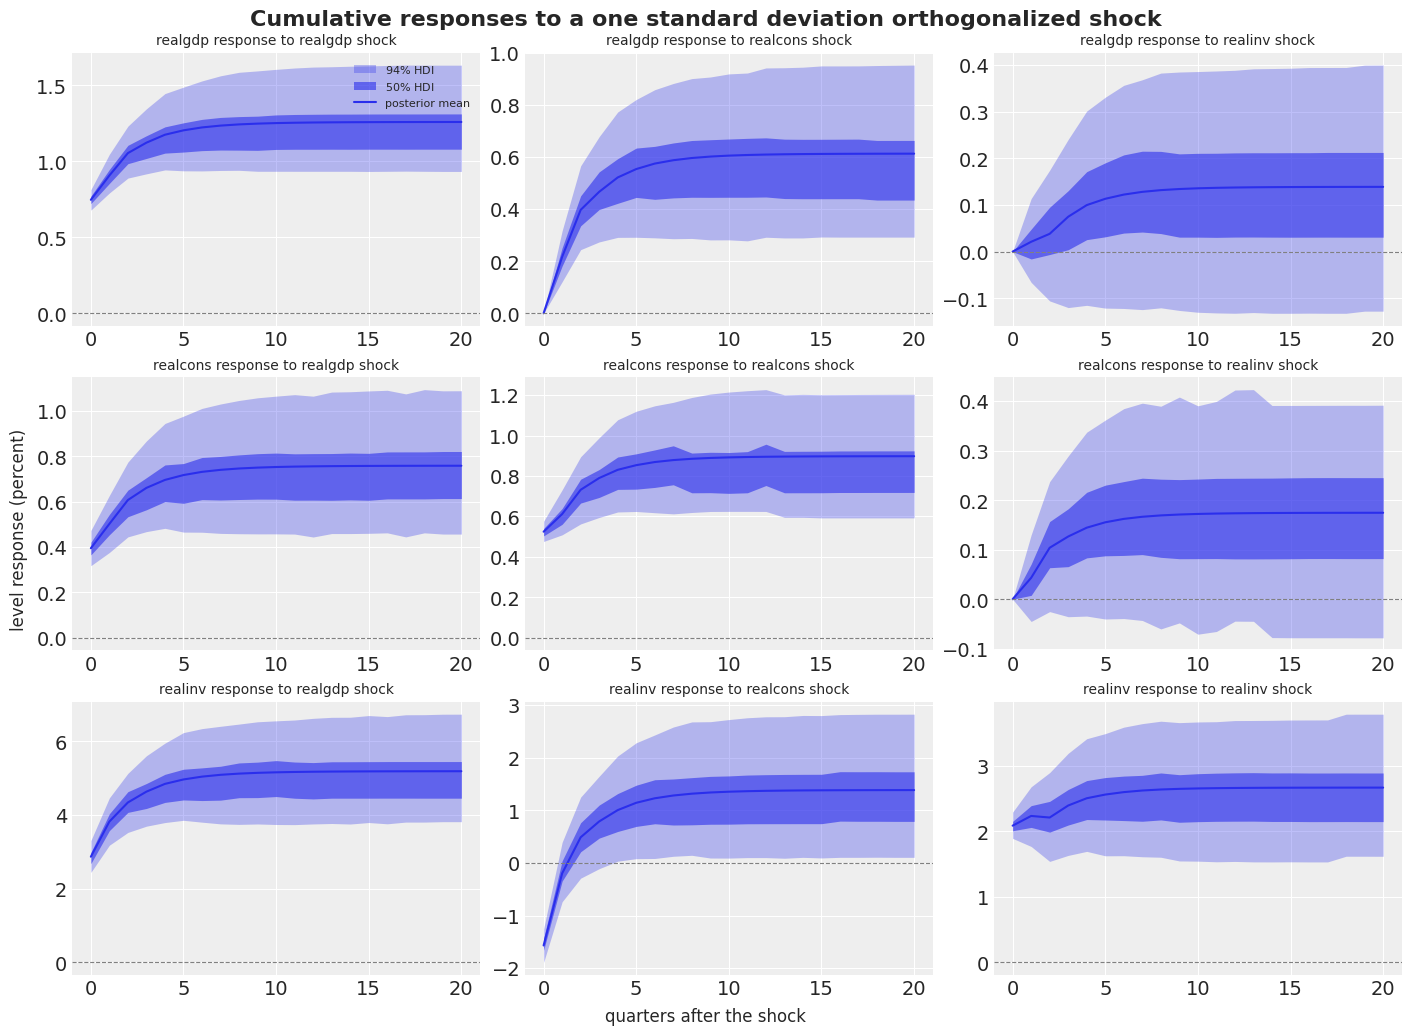

In [20]:
plot_irf_grid(
    irf_level_draws,
    title="Cumulative responses to a one standard deviation orthogonalized shock",
    ylabel="level response (percent)",
)

## Minnesota prior

A VAR has many coefficients for its sample size: here $18$ lag coefficients plus $3$ intercepts for $200$ quarters, and the count grows with $p k^2$. Unregularized fits overfit and forecast poorly. Litterman (1986) and Doan, Litterman and Sims (1984) proposed the *Minnesota prior*, which encodes three beliefs:

1. Each series is close to a univariate process: the prior mean of the first own lag is $m_{\text{own}}$ and every other coefficient is centered at zero. For series in levels $m_{\text{own}} = 1$ (a random walk); for differenced or otherwise stationary series, as here, $m_{\text{own}} = 0$.
2. Longer lags matter less: the prior standard deviation decays with the lag, $d(l) = 1/l$ (harmonic) or $1/l^2$.
3. Other series matter less than the own past: cross-variable coefficients get a tighter prior by a factor $\kappa \in [0, 1]$.

Together, for the coefficient of series $j$ at lag $l$ in the equation of series $i$,

$$
\Phi_{l, ij} \sim \text{Normal}\left(m_{l, ij}, \; \lambda \, d(l) \, \kappa^{[i \neq j]}\right),
\qquad
m_{l, ij} = m_{\text{own}} \, [l = 1] \, [i = j],
$$

with an overall tightness $\lambda$. `minnesota_prior(n_lags, n_obs, tightness, cross_shrinkage, decay, own_lag_mean)` returns the `loc` and `scale` arrays in the `(lags, series, series)` layout of `var_step`, and we pass them to `dist.Normal(...).to_event(3)`. Nothing else changes: the prior is an argument of the model factory.

This parameterization follows [Impulso's `MinnesotaPrior`](https://thomaspinder.github.io/Impulso/reference/generated/impulso.priors.MinnesotaPrior.html): the same three knobs (`tightness`, `decay`, `cross_shrinkage`) and a tightness that is fixed rather than estimated. There is no closed-form marginal likelihood for the independent-normal prior, so Impulso treats the tightness as a modeling choice, and so do we. Two differences: Impulso calls the $1/l^2$ decay "geometric" (in Doan, Litterman and Sims it is the harmonic decay with exponent two), and it fixes the own-lag mean at one, while we expose `own_lag_mean` because differenced data call for zero.

### Series on different scales

The classic Litterman formulation multiplies the standard deviation of the cross-variable coefficients by $\sigma_i / \sigma_j$, the ratio of the residual standard deviations of the two series. Impulso omits this factor and asks for pre-scaled data. Our series are not on a common scale: investment growth is about five times more volatile than GDP or consumption growth, so the investment equation carries coefficients about five times larger, and a common tightness would shrink them five times too hard. We apply the classic correction with the sample standard deviations as a proxy for the residual scales. The table shows the ratios $\sigma_i / \sigma_j$ (rows: equation, columns: lagged series).

In [21]:
sample_sd = y_pct.std().to_numpy()
scale_ratio = sample_sd[:, None] / sample_sd[None, :]
pd.DataFrame(scale_ratio, index=names, columns=names).round(2)

,realgdp,realcons,realinv
realgdp,1.00,1.27,0.19
realcons,0.79,1.00,0.15
realinv,5.33,6.75,1.00


With $\lambda = 0.5$ and $\kappa = 0.5$ the prior standard deviation of a first-lag cross coefficient is $0.25$ before scaling. The printout compares, for the investment equation at lag one, the unscaled (Impulso-style) prior standard deviations, the scaled ones we use, and the posterior under the weak prior: the coefficient on lagged consumption growth has a posterior mean near $2.8$ with a standard deviation near $0.5$, so an unscaled prior with standard deviation $0.25$ sits more than ten prior standard deviations away from what the data say and would dominate the posterior, while the scaled prior is compatible with it.

In [22]:
tightness = 0.5
loc_mn, scale_unscaled = minnesota_prior(
    p, k, tightness=tightness, cross_shrinkage=0.5, own_lag_mean=0.0
)
scale_mn = scale_unscaled * jnp.asarray(scale_ratio, dtype=scale_unscaled.dtype)
minnesota = dist.Normal(loc_mn, scale_mn).to_event(3)

phi_weak_mean = np.asarray(posterior["phi"]).mean(axis=0)
phi_weak_sd = np.asarray(posterior["phi"]).std(axis=0)
pd.DataFrame(
    {
        "unscaled prior sd": np.asarray(scale_unscaled[0, 2]),
        "scaled prior sd": np.asarray(scale_mn[0, 2]),
        "weak prior posterior mean": phi_weak_mean[0, 2],
        "weak prior posterior sd": phi_weak_sd[0, 2],
    },
    index=pd.Index(names, name="lagged series (realinv equation, lag 1)"),
).round(3)

,unscaled prior sd,scaled prior sd,weak prior posterior mean,weak prior posterior sd
"lagged series (realinv equation, lag 1)",,,,
realgdp,0.25,1.331,-0.490,0.608
realcons,0.25,1.687,2.821,0.498
realinv,0.50,0.500,0.071,0.104


In [23]:
var_model_mn = make_var_model(minnesota, y_init)

rng_key, rng_subkey = random.split(rng_key)
mcmc_mn = fit_nuts(rng_subkey, var_model_mn, data, covariates_train)
posterior_mn = mcmc_mn.get_samples()
print(f"divergences: {n_divergences(mcmc_mn)}")

rng_key, rng_subkey = random.split(rng_key)
tree_mn = export(rng_subkey, var_model_mn, posterior_mn)
summary_mn = az.summary(
    tree_mn, var_names=["intercept", "sigma", "phi"], ci_kind="hdi", ci_prob=0.94
)
print(convergence_line(summary_mn))

divergences: 0


max r_hat: 1.000, min ess_bulk: 2020


### Shrinkage of the coefficients

The table compares the posterior standard deviation of every coefficient under the two priors. The ratio column is below one where the Minnesota prior tightened the posterior. The effect is largest on the second lag, where the harmonic decay halves the prior standard deviation, and on the GDP and consumption equations. The investment equation at lag one is unchanged within Monte Carlo error: after the scale correction its prior is wide relative to what the data say, so the data decide.

In [24]:
phi_index = pd.MultiIndex.from_product(
    [list(range(1, p + 1)), names, names], names=["lag", "equation", "lagged series"]
)
phi_sd = pd.DataFrame(
    {
        "weak prior": phi_weak_sd.reshape(-1),
        "minnesota prior": np.asarray(posterior_mn["phi"]).std(axis=0).reshape(-1),
    },
    index=phi_index,
)
phi_sd["ratio"] = phi_sd["minnesota prior"] / phi_sd["weak prior"]
own = phi_sd.index.get_level_values("equation") == phi_sd.index.get_level_values("lagged series")
print(
    f"mean ratio on own lags: {phi_sd.loc[own, 'ratio'].mean():.2f}, "
    f"on cross lags: {phi_sd.loc[~own, 'ratio'].mean():.2f}"
)
phi_sd.round(3)

mean ratio on own lags: 0.79, on cross lags: 0.76


weak prior  minnesota prior  ratio
lag equation lagged series                                    
1   realgdp  realgdp             0.140            0.119  0.846
             realcons            0.114            0.101  0.889
             realinv             0.023            0.018  0.803
    realcons realgdp             0.144            0.105  0.730
             realcons            0.113            0.094  0.831
             realinv             0.022            0.016  0.727
    realinv  realgdp             0.608            0.650  1.069
             realcons            0.498            0.542  1.088
             realinv             0.104            0.101  0.971
2   realgdp  realgdp             0.141            0.085  0.600
             realcons            0.123            0.083  0.673
             realinv             0.022            0.014  0.617
    realcons realgdp             0.144            0.070  0.488
             realcons            0.123            0.086  0.696
             realinv             0.022            0.011  0.532
    realinv  realgdp             0.616            0.445  0.722
             realcons            0.543            0.433  0.798
             realinv             0.101            0.079  0.780

### Forecast bands

Tighter coefficients mean less parameter uncertainty in the forecast. The table reports the mean width of the $94\%$ HDI over the 30 forecast quarters, per series and per prior. The change is small: a few percent for GDP and consumption and none for investment. With 200 quarters for 18 coefficients, the forecast uncertainty comes from the shock covariance, not from the coefficients, and a prior of this tightness cannot move it much.

In [25]:
forecast_draws_mn = stack_draws("predictions", tree_mn)
pd.DataFrame(
    {
        "weak prior": width_94.mean(axis=0),
        "minnesota prior": hdi_width(forecast_draws_mn, 0.94).mean(axis=0),
    },
    index=names,
).round(3)

,weak prior,minnesota prior
realgdp,3.205,3.161
realcons,2.700,2.626
realinv,16.513,16.557


### Impulse responses

The grid overlays the posterior mean responses under the Minnesota prior (orange) on the bands and mean of the weak prior fit (blue). The two means agree closely and the orange line stays inside the $50\%$ band of the weak prior fit in every panel. The Minnesota mean is smoother at two and three quarters after the shock, where the prior halves the standard deviation of the second-lag coefficients and irons out the wiggle that the weak prior fit shows there. With 200 quarters for 18 coefficients the data dominate a prior of this tightness; a smaller `tightness` trades this agreement for more shrinkage.

stable draws (Minnesota prior): 1.000


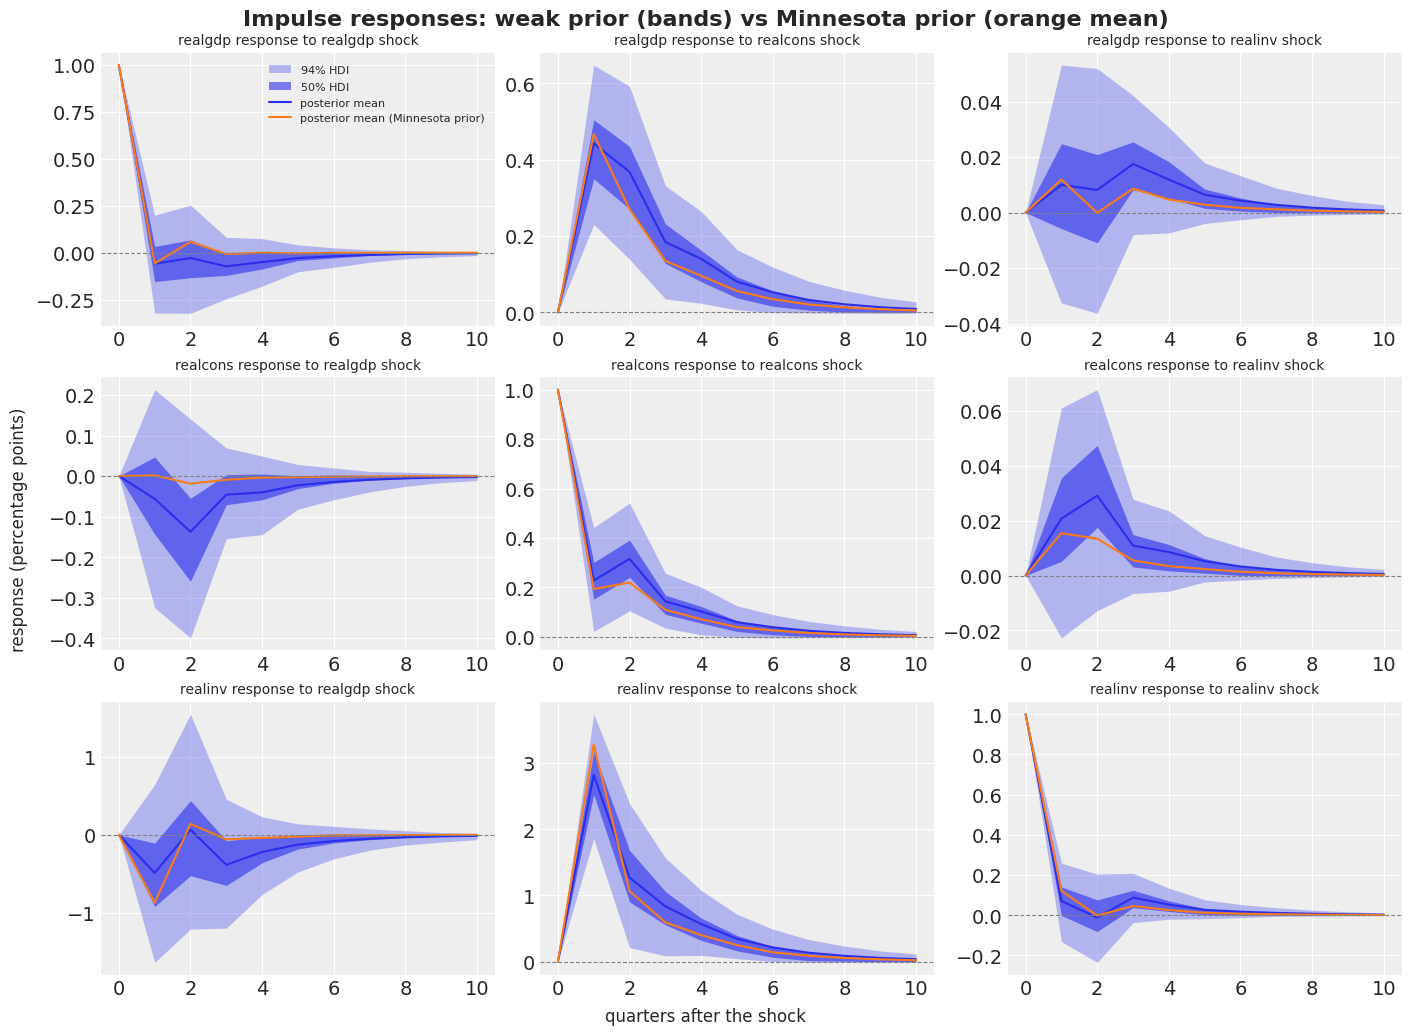

In [26]:
phi_draws_mn = jnp.asarray(posterior_mn["phi"])
radius_mn = np.abs(np.linalg.eigvals(np.asarray(companion_matrix(phi_draws_mn)))).max(axis=-1)
stable_mn = radius_mn < 1.0
print(f"stable draws (Minnesota prior): {stable_mn.mean():.3f}")
irf_draws_mn = impulse_response(phi_draws_mn[stable_mn], n_irf_steps)
plot_irf_grid(
    irf_draws,
    title="Impulse responses: weak prior (bands) vs Minnesota prior (orange mean)",
    ylabel="response (percentage points)",
    overlay=irf_draws_mn,
    overlay_label="posterior mean (Minnesota prior)",
)

The tightness $\lambda$ is a modeling choice, not an estimate: there is no closed-form marginal likelihood for the independent-normal prior to optimize it, so pick it from the scale of the coefficients you find plausible, or compare forecast scores across a few values with `backtest`.

## References

- Orduz, J. [Bayesian VAR in NumPyro](https://juanitorduz.github.io/var_numpyro/). The source of this notebook.
- Lütkepohl, H. (2005). *New Introduction to Multiple Time Series Analysis*. Springer. Chapters 2 and 5 cover the moving-average representation, impulse responses and the Minnesota prior.
- Litterman, R. B. (1986). Forecasting with Bayesian vector autoregressions: five years of experience. *Journal of Business & Economic Statistics*, 4(1), 25-38.
- Doan, T., Litterman, R. B. and Sims, C. A. (1984). Forecasting and conditional projection using realistic prior distributions. *Econometric Reviews*, 3(1), 1-100.
- Pinder, T. [Impulso](https://github.com/thomaspinder/impulso): a Bayesian VAR package for Python ([documentation](https://thomaspinder.github.io/Impulso/), [`MinnesotaPrior` reference](https://thomaspinder.github.io/Impulso/reference/generated/impulso.priors.MinnesotaPrior.html)). The Minnesota prior parameterization and the batched moving-average recursion used here follow its design.
- statsmodels. [macrodata](https://www.statsmodels.org/stable/datasets/generated/macrodata.html): United States macroeconomic data, 1959Q1 to 2009Q3, public domain.